# End-to-End Book Recommender System

Notebook ini memperlihatkan proses dari awal sampai akhir untuk membangun sistem
rekomendasi buku berbasis dataset Kaggle Book Recommendation Dataset.

Tujuan notebook:

- memahami struktur dan kualitas data
- membersihkan data buku, rating, dan user
- membangun rekomendasi content-based dari metadata buku
- membangun rekomendasi collaborative filtering dari histori rating user
- mengevaluasi hasil secara sederhana dan menjelaskan keterbatasannya

Kode utama sengaja disimpan di `src/book_recommender` supaya notebook ini tetap
fokus pada narasi, eksplorasi, dan hasil.

In [1]:
from pathlib import Path

import gc

import matplotlib
try:
    get_ipython
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from book_recommender.collaborative import ItemBasedCollaborativeRecommender
from book_recommender.content_based import ContentBasedRecommender
from book_recommender.data import dataset_summary, load_raw_data, prepare_dataset, validate_data_dir
from book_recommender.evaluation import build_leave_one_out_split, ranking_metrics_at_k

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

## 1. Konfigurasi

Dataset tidak disimpan di git. Unduh dataset dari Kaggle:

https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset

Lalu letakkan file berikut di `data/raw/`:

- `Books.csv`
- `Ratings.csv`
- `Users.csv`

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Parameter ini sengaja dibuat eksplisit agar eksperimen mudah diulang.
# Naikkan MAX_BOOKS jika ingin eksperimen yang lebih besar.
MAX_BOOKS = 5_000
MIN_USER_RATINGS = 2
MIN_BOOK_RATINGS = 2
RANDOM_STATE = 42

validate_data_dir(DATA_DIR)
DATA_DIR

WindowsPath('D:/Dikoding/Machine Learning/Applied- Machine Learning/recommender system/data/raw')

## 2. Data Understanding

Dataset terdiri dari tiga file utama:

- `Books.csv`: metadata buku
- `Ratings.csv`: rating buku dari user
- `Users.csv`: metadata user

In [3]:
raw = load_raw_data(DATA_DIR)

raw_shapes = pd.DataFrame(
    {
        "dataset": ["Books", "Ratings", "Users"],
        "rows": [len(raw.books), len(raw.ratings), len(raw.users)],
        "columns": [raw.books.shape[1], raw.ratings.shape[1], raw.users.shape[1]],
    }
)
display(raw_shapes)

,dataset,rows,columns
0,Books,271360,8
1,Ratings,1149780,3
2,Users,278858,3


In [4]:
display(raw.books.head())
display(raw.ratings.head())
display(raw.users.head())

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.LZZZZZZZ.jpg
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.LZZZZZZZ.jpg
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.LZZZZZZZ.jpg
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for th...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0374157065.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0374157065.01.LZZZZZZZ.jpg
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0393045218.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0393045218.01.LZZZZZZZ.jpg


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


### Missing Value

Missing value paling jelas berada pada kolom `Age` di data user. Untuk model
rekomendasi yang dibangun di notebook ini, fitur umur tidak dipakai langsung,
tetapi pengecekan tetap dilakukan agar kualitas data terlihat.

In [5]:
missing_summary = pd.concat(
    {
        "books": raw.books.isna().sum(),
        "ratings": raw.ratings.isna().sum(),
        "users": raw.users.isna().sum(),
    },
    axis=1,
).fillna(0).astype("int64")

display(missing_summary)

,books,ratings,users
ISBN,0,0,0
Book-Title,0,0,0
Book-Author,2,0,0
Year-Of-Publication,0,0,0
Publisher,2,0,0
Image-URL-S,0,0,0
Image-URL-M,0,0,0
Image-URL-L,3,0,0
User-ID,0,0,0
Book-Rating,0,0,0


### Distribusi Rating

Rating `0` pada dataset ini diperlakukan sebagai belum memberi rating eksplisit.
Untuk recommender berbasis rating eksplisit, rating `0` dibuang pada tahap
preprocessing.

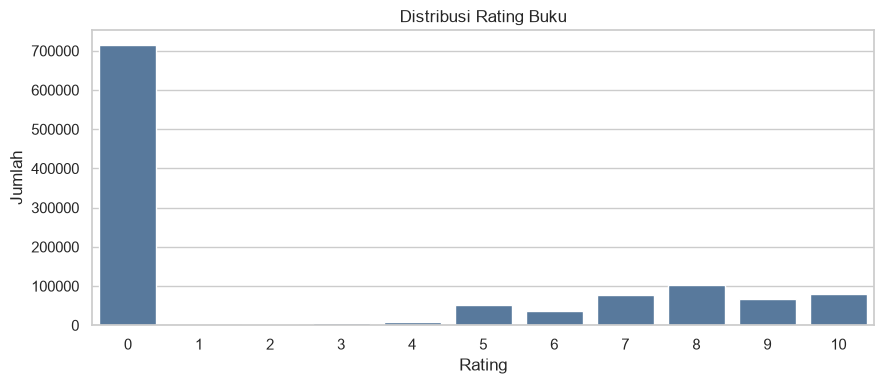

,Book-Rating,count
0,0,716109
1,1,1770
2,2,2759
3,3,5996
4,4,8904
5,5,50974
6,6,36924
7,7,76457
8,8,103736
9,9,67541


In [6]:
rating_counts = raw.ratings["Book-Rating"].value_counts().sort_index()

plt.figure(figsize=(9, 4))
sns.barplot(x=rating_counts.index.astype(str), y=rating_counts.values, color="#4C78A8")
plt.title("Distribusi Rating Buku")
plt.xlabel("Rating")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

display(rating_counts.rename("count").reset_index().rename(columns={"index": "rating"}))

In [7]:
del raw
gc.collect()

195

## 3. Data Preparation

Tahap preparation dilakukan melalui fungsi di `book_recommender.data`:

- rename kolom agar konsisten
- hapus rating `0`
- hapus record yang tidak punya ISBN atau judul
- filter interaksi sparse
- ambil `MAX_BOOKS` buku yang paling banyak dirating

Pengambilan buku berdasarkan jumlah rating lebih defensible daripada slicing
`books[:10000]`, karena tidak bergantung pada urutan file mentah.

In [8]:
dataset = prepare_dataset(
    DATA_DIR,
    min_user_ratings=MIN_USER_RATINGS,
    min_book_ratings=MIN_BOOK_RATINGS,
    max_books=MAX_BOOKS,
    random_state=RANDOM_STATE,
)

summary = pd.Series(dataset_summary(dataset), name="value").to_frame()
display(summary)

,value
books,5000
ratings,117726
users,278858
rated_books,5000
rating_users,20827


In [9]:
display(dataset.books.head())
display(dataset.ratings.head())

,isbn,book_title,book_author,pub_year,publisher,image_s_url,image_m_url,image_l_url
0,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,http://images.amazon.com/images/P/0399135782.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0399135782.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0399135782.01.LZZZZZZZ.jpg
1,0440234743,The Testament,John Grisham,1999,Dell,http://images.amazon.com/images/P/0440234743.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0440234743.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0440234743.01.LZZZZZZZ.jpg
2,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,1994,Plume,http://images.amazon.com/images/P/0452264464.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0452264464.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0452264464.01.LZZZZZZZ.jpg
3,0609804618,Our Dumb Century: The Onion Presents 100 Years of Headlines from America's F...,The Onion,1999,Three Rivers Press,http://images.amazon.com/images/P/0609804618.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0609804618.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0609804618.01.LZZZZZZZ.jpg
4,0971880107,Wild Animus,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0971880107.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0971880107.01.LZZZZZZZ.jpg


,user_id,isbn,book_rating
0,276747,0060517794,9.0
1,276747,0671537458,9.0
2,276747,0679776818,8.0
3,276762,0380711524,5.0
4,276788,0345443683,8.0


### Buku dan User Paling Aktif

In [10]:
book_popularity = (
    dataset.ratings.groupby("isbn")
    .agg(mean_rating=("book_rating", "mean"), rating_count=("book_rating", "size"))
    .reset_index()
    .merge(dataset.books, on="isbn", how="left")
    .sort_values(["rating_count", "mean_rating"], ascending=False)
)

display(
    book_popularity[
        ["isbn", "book_title", "book_author", "mean_rating", "rating_count"]
    ].head(10)
)

,isbn,book_title,book_author,mean_rating,rating_count
760,0316666343,The Lovely Bones: A Novel,Alice Sebold,8.206897,551
1628,0385504209,The Da Vinci Code,Dan Brown,8.502463,406
4722,0971880107,Wild Animus,Rich Shapero,4.054348,368
615,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant,8.250000,300
139,0060928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,7.897436,273
3535,059035342X,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling,8.921641,268
541,0142001740,The Secret Life of Bees,Sue Monk Kidd,8.488372,258
3693,0671027360,Angels &amp; Demons,Dan Brown,8.056680,247
2551,0446672211,Where the Heart Is (Oprah's Book Club (Paperback)),Billie Letts,8.199153,236
2910,0452282152,Girl with a Pearl Earring,Tracy Chevalier,7.987013,231


In [11]:
user_activity = dataset.ratings["user_id"].value_counts().head(10)
display(user_activity.rename_axis("user_id").reset_index(name="rating_count"))

,user_id,rating_count
0,11676,1866
1,16795,327
2,98391,317
3,153662,301
4,95359,273
5,104636,269
6,114368,264
7,158295,200
8,123883,198
9,60244,197


## 4. Content-Based Recommendation

Pendekatan content-based memakai teks metadata:

```text
book_title + book_author + publisher
```

Teks tersebut diubah menjadi TF-IDF vector, lalu buku terdekat dicari dengan
cosine distance.

In [12]:
content_model = ContentBasedRecommender().fit(dataset.books)

query_title = "Adventures of Huckleberry Finn"
content_recommendations = content_model.recommend_similar(title=query_title, top_n=10)

display(
    content_recommendations[
        ["score", "isbn", "book_title", "book_author", "publisher", "image_m_url"]
    ]
)

,score,isbn,book_title,book_author,publisher,image_m_url
0,0.571552,0553210793,The Adventures of Huckleberry Finn (Bantam Classics),MARK TWAIN,Bantam,http://images.amazon.com/images/P/0553210793.01.MZZZZZZZ.jpg
1,0.551028,0140390464,The Adventures of Huckleberry Finn (Penguin Classics),Mark Twain,Penguin Books,http://images.amazon.com/images/P/0140390464.01.MZZZZZZZ.jpg
2,0.342196,0451524667,Animal Farm,George Orwell,New Amer Library Classics,http://images.amazon.com/images/P/0451524667.01.MZZZZZZZ.jpg
3,0.316426,0451149513,It,Stephen King,New Amer Library,http://images.amazon.com/images/P/0451149513.01.MZZZZZZZ.jpg
4,0.303391,0451153553,Misery,Stephen King,New Amer Library,http://images.amazon.com/images/P/0451153553.01.MZZZZZZZ.jpg
5,0.300205,0451137965,Thinner,Stephen King,New Amer Library,http://images.amazon.com/images/P/0451137965.01.MZZZZZZZ.jpg
6,0.269515,0451099648,Firestarter (Signet Book),Stephen King,New Amer Library,http://images.amazon.com/images/P/0451099648.01.MZZZZZZZ.jpg
7,0.268439,0451519841,1984,George Orwell,New Amer Library,http://images.amazon.com/images/P/0451519841.01.MZZZZZZZ.jpg
8,0.267299,0451142934,Skeleton Crew,Stephen King,New Amer Library,http://images.amazon.com/images/P/0451142934.01.MZZZZZZZ.jpg
9,0.266471,0451184114,Dolores Claiborne,Stephen King,New Amer Library,http://images.amazon.com/images/P/0451184114.01.MZZZZZZZ.jpg


Hasil di atas bisa dibaca sebagai buku yang metadata-nya paling mirip dengan
query. Untuk contoh ini, hasil yang baik seharusnya berisi edisi lain dari
`Huckleberry Finn`, buku lain dari Mark Twain, atau buku dari publisher/seri
yang relevan.

## 5. Collaborative Filtering

Pendekatan collaborative filtering memakai histori rating user. Model yang
dipakai di sini adalah item-item collaborative filtering:

- membuat sparse matrix `book x user`
- mencari buku yang memiliki pola rating mirip
- merekomendasikan buku mirip dengan buku yang disukai user

Pendekatan ini lebih ringan daripada deep learning dan cocok untuk baseline
project yang reproducible.

In [13]:
collab_model = ItemBasedCollaborativeRecommender(n_neighbors=50).fit(
    dataset.books,
    dataset.ratings,
)

candidate_user_id = 5709
if candidate_user_id not in set(dataset.ratings["user_id"]):
    candidate_user_id = int(dataset.ratings["user_id"].value_counts().index[0])

user_history = (
    dataset.ratings[dataset.ratings["user_id"] == candidate_user_id]
    .sort_values("book_rating", ascending=False)
    .merge(dataset.books, on="isbn", how="left")
)

display(user_history[["isbn", "book_title", "book_author", "book_rating"]].head(10))

,isbn,book_title,book_author,book_rating
0,0684832178,CHOCOLATE FOR A WOMANS SOUL : 77 STORIES TO FEED YOUR SPIRIT AND WARM YOUR H...,Kay Allenbaugh,9.0
1,0380807343,Coraline,Neil Gaiman,8.0
2,0064472779,All-American Girl,Meg Cabot,7.0
3,0553577123,The Diary of a Young Girl: The Definitive Edition,Anne Frank,5.0


In [14]:
collab_recommendations = collab_model.recommend_for_user(candidate_user_id, top_n=10)

display(
    collab_recommendations[
        ["score", "isbn", "book_title", "book_author", "publisher", "image_m_url"]
    ]
)

,score,isbn,book_title,book_author,publisher,image_m_url
0,0.189522,0671769200,If You Really Loved Me,Ann Rule,Pocket,http://images.amazon.com/images/P/0671769200.01.MZZZZZZZ.jpg
1,0.163797,0380782340,Nobody's Baby But Mine,Susan Elizabeth Phillips,Avon,http://images.amazon.com/images/P/0380782340.01.MZZZZZZZ.jpg
2,0.153305,0684848961,Chocolate For A Womans Heart : 77 Stories Of Love Kindness And Compassion To...,Kay Allenbaugh,Fireside,http://images.amazon.com/images/P/0684848961.01.MZZZZZZZ.jpg
3,0.142257,0786883375,Don't Sweat the Small Stuff with Your Family : Simple Ways to Keep Daily Res...,Richard Carlson,Hyperion,http://images.amazon.com/images/P/0786883375.01.MZZZZZZZ.jpg
4,0.135278,1551669498,Girls Night,Stef Ann Holm,Mira,http://images.amazon.com/images/P/1551669498.01.MZZZZZZZ.jpg
5,0.132328,0743403614,Orphans (Orphans Series),V.C. Andrews,Pocket,http://images.amazon.com/images/P/0743403614.01.MZZZZZZZ.jpg
6,0.128156,0380730200,The Giant's House : A Romance,Elizabeth McCracken,Perennial,http://images.amazon.com/images/P/0380730200.01.MZZZZZZZ.jpg
7,0.126333,0385336489,Niagara Falls All Over Again,Elizabeth McCracken,Delta,http://images.amazon.com/images/P/0385336489.01.MZZZZZZZ.jpg
8,0.123705,0060934719,stardust,Neil Gaiman,Perennial,http://images.amazon.com/images/P/0060934719.01.MZZZZZZZ.jpg
9,0.122920,0425171493,Framed in Lace (Needlecraft Mysteries),Monica Ferris,Prime Crime,http://images.amazon.com/images/P/0425171493.01.MZZZZZZZ.jpg


## 6. Evaluasi Sederhana

Untuk gambaran awal, notebook ini memakai evaluasi leave-one-out kecil:

- pilih sebagian user yang punya minimal 3 rating
- tahan satu buku dengan rating tinggi sebagai data relevan
- latih recommender tanpa rating yang ditahan
- cek apakah buku yang ditahan muncul di Top-K rekomendasi
- bandingkan collaborative filtering dengan popularity baseline

Evaluasi ini belum sekuat eksperimen produksi, tetapi lebih baik daripada
klaim akurasi manual tanpa target yang jelas. Karena dataset sangat sparse,
Top-50 dipakai untuk membaca sinyal baseline awal. Metrik yang dipakai:
Precision@K, Recall@K, HitRate@K, MAP@K, dan NDCG@K.

In [15]:
train_ratings, holdout_ratings = build_leave_one_out_split(
    dataset.ratings,
    sample_users=20,
    random_state=RANDOM_STATE,
)

eval_model = ItemBasedCollaborativeRecommender(n_neighbors=100).fit(
    dataset.books,
    train_ratings,
)

k = 50
metric_rows = []
for row in holdout_ratings.itertuples(index=False):
    user_id = int(row.user_id)
    relevant = [row.isbn]
    collab_recommended = eval_model.recommend_for_user(user_id, top_n=k)["isbn"].tolist()
    train_history = train_ratings[train_ratings["user_id"] == user_id]
    popularity_recommended = eval_model.recommend_popular(
        top_n=k,
        exclude_isbns=set(train_history["isbn"]),
    )["isbn"].tolist()

    metric_rows.append(
        {"model": "collaborative", "user_id": user_id, **ranking_metrics_at_k(collab_recommended, relevant, k)}
    )
    metric_rows.append(
        {"model": "popularity", "user_id": user_id, **ranking_metrics_at_k(popularity_recommended, relevant, k)}
    )

metrics = pd.DataFrame(metric_rows)
display(metrics.head())
metric_columns = [
    f"precision_at_{k}",
    f"recall_at_{k}",
    f"hit_rate_at_{k}",
    f"map_at_{k}",
    f"ndcg_at_{k}",
]
display(metrics.groupby("model")[metric_columns].mean())

,model,user_id,precision_at_50,recall_at_50,hit_rate_at_50,map_at_50,ndcg_at_50
0,collaborative,188027,0.0,0.0,0.0,0.0,0.0
1,popularity,188027,0.0,0.0,0.0,0.0,0.0
2,collaborative,169450,0.0,0.0,0.0,0.0,0.0
3,popularity,169450,0.0,0.0,0.0,0.0,0.0
4,collaborative,233711,0.0,0.0,0.0,0.0,0.0


,precision_at_50,recall_at_50,hit_rate_at_50,map_at_50,ndcg_at_50
model,,,,,
collaborative,0.002,0.10,0.10,0.003282,0.020032
popularity,0.001,0.05,0.05,0.016667,0.025000


## 7. Kesimpulan

Dari notebook ini:

- Dataset dapat diproses ulang dari file mentah Kaggle.
- Content-based recommendation cocok untuk mencari buku mirip berdasarkan
  metadata, termasuk saat user belum punya histori rating.
- Collaborative filtering cocok ketika user sudah memiliki histori rating,
  karena rekomendasi berasal dari pola kesukaan user lain.
- Evaluasi awal sudah memakai target holdout, tetapi masih terbatas karena
  hanya mengevaluasi sampel kecil dan belum memakai split temporal.

Pengembangan lanjutan yang masuk akal:

- simpan model sebagai artifact di `models/`
- tambah Streamlit demo dengan cover buku
- eksperimen hybrid recommender yang menggabungkan metadata dan rating
- perluas evaluasi ranking dengan split temporal dan sampel user yang lebih
  besar